In [23]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [24]:
train_transaction = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
train_identity = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')
test_transaction = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv')
test_identity = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv')

In [25]:
train_df = train_identity.merge(train_transaction)

In [26]:
train_transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [27]:
train_transaction.shape

(590540, 394)

In [28]:
train_transaction.isna().sum()

TransactionID          0
isFraud                0
TransactionDT          0
TransactionAmt         0
ProductCD              0
                   ...  
V335              508189
V336              508189
V337              508189
V338              508189
V339              508189
Length: 394, dtype: int64

### Dropping v339

In [29]:
for i in train_transaction.columns:
    no = train_transaction[i].isna().sum()
    if no > 50000:
        print(i,':',no.sum())
print(f'Highest missing val ;{i}')
    

addr1 : 65706
addr2 : 65706
dist1 : 352271
dist2 : 552913
P_emaildomain : 94456
R_emaildomain : 453249
D2 : 280797
D3 : 262878
D4 : 168922
D5 : 309841
D6 : 517353
D7 : 551623
D8 : 515614
D9 : 515614
D10 : 76022
D11 : 279287
D12 : 525823
D13 : 528588
D14 : 528353
D15 : 89113
M1 : 271100
M2 : 271100
M3 : 271100
M4 : 281444
M5 : 350482
M6 : 169360
M7 : 346265
M8 : 346252
M9 : 346252
V1 : 279287
V2 : 279287
V3 : 279287
V4 : 279287
V5 : 279287
V6 : 279287
V7 : 279287
V8 : 279287
V9 : 279287
V10 : 279287
V11 : 279287
V12 : 76073
V13 : 76073
V14 : 76073
V15 : 76073
V16 : 76073
V17 : 76073
V18 : 76073
V19 : 76073
V20 : 76073
V21 : 76073
V22 : 76073
V23 : 76073
V24 : 76073
V25 : 76073
V26 : 76073
V27 : 76073
V28 : 76073
V29 : 76073
V30 : 76073
V31 : 76073
V32 : 76073
V33 : 76073
V34 : 76073
V35 : 168969
V36 : 168969
V37 : 168969
V38 : 168969
V39 : 168969
V40 : 168969
V41 : 168969
V42 : 168969
V43 : 168969
V44 : 168969
V45 : 168969
V46 : 168969
V47 : 168969
V48 : 168969
V49 : 168969
V50 : 168969

In [30]:
small_df = train_transaction.dropna(subset=['V339'])

In [31]:
small_df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,2987008,0,86535,15.0,H,2803,100.0,150.0,visa,226.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16,2987016,0,86620,30.0,H,1790,555.0,150.0,visa,226.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17,2987017,0,86668,100.0,H,11492,111.0,150.0,mastercard,219.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
22,2987022,0,86786,50.0,H,1724,583.0,150.0,visa,226.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
small_df.shape

(82351, 394)

In [33]:
small_df.isna().sum()

TransactionID     0
isFraud           0
TransactionDT     0
TransactionAmt    0
ProductCD         0
                 ..
V335              0
V336              0
V337              0
V338              0
V339              0
Length: 394, dtype: int64

In [34]:
for col in small_df.columns:
    num = small_df[col].isna().sum()
    if num > 0:
        print(col,':',num.sum())

card2 : 397
card3 : 1
card4 : 11
card5 : 583
card6 : 7
addr1 : 343
addr2 : 343
dist1 : 82351
dist2 : 71465
P_emaildomain : 11674
R_emaildomain : 11426
D1 : 41
D2 : 69728
D3 : 77844
D4 : 76131
D5 : 79085
D6 : 73516
D7 : 75937
D8 : 36861
D9 : 36861
D10 : 72272
D11 : 82351
D12 : 82351
D13 : 78347
D14 : 71247
D15 : 72785
M1 : 82351
M2 : 82351
M3 : 82351
M4 : 82351
M5 : 82351
M6 : 82351
M7 : 82351
M8 : 82351
M9 : 82351
V1 : 82351
V2 : 82351
V3 : 82351
V4 : 82351
V5 : 82351
V6 : 82351
V7 : 82351
V8 : 82351
V9 : 82351
V10 : 82351
V11 : 82351
V12 : 72323
V13 : 72323
V14 : 72323
V15 : 72323
V16 : 72323
V17 : 72323
V18 : 72323
V19 : 72323
V20 : 72323
V21 : 72323
V22 : 72323
V23 : 72323
V24 : 72323
V25 : 72323
V26 : 72323
V27 : 72323
V28 : 72323
V29 : 72323
V30 : 72323
V31 : 72323
V32 : 72323
V33 : 72323
V34 : 72323
V35 : 76154
V36 : 76154
V37 : 76154
V38 : 76154
V39 : 76154
V40 : 76154
V41 : 76154
V42 : 76154
V43 : 76154
V44 : 76154
V45 : 76154
V46 : 76154
V47 : 76154
V48 : 76154
V49 : 76154
V50

In [35]:
cols_to_drop = [col for col in small_df.columns if small_df[col].isna().sum() > 15000]
df_small = small_df.drop(columns=cols_to_drop)
df_small.shape

(82351, 275)

In [36]:
for i in df_small.columns:
    print(i, df_small[i].isna().sum())
    

TransactionID 0
isFraud 0
TransactionDT 0
TransactionAmt 0
ProductCD 0
card1 0
card2 397
card3 1
card4 11
card5 583
card6 7
addr1 343
addr2 343
P_emaildomain 11674
R_emaildomain 11426
C1 0
C2 0
C3 0
C4 0
C5 0
C6 0
C7 0
C8 0
C9 0
C10 0
C11 0
C12 0
C13 0
C14 0
D1 41
V95 0
V96 0
V97 0
V98 0
V99 0
V100 0
V101 0
V102 0
V103 0
V104 0
V105 0
V106 0
V107 0
V108 0
V109 0
V110 0
V111 0
V112 0
V113 0
V114 0
V115 0
V116 0
V117 0
V118 0
V119 0
V120 0
V121 0
V122 0
V123 0
V124 0
V125 0
V126 0
V127 0
V128 0
V129 0
V130 0
V131 0
V132 0
V133 0
V134 0
V135 0
V136 0
V137 0
V138 406
V139 406
V140 406
V141 406
V142 406
V143 400
V144 400
V145 400
V146 406
V147 406
V148 406
V149 406
V150 400
V151 400
V152 400
V153 406
V154 406
V155 406
V156 406
V157 406
V158 406
V159 400
V160 400
V161 406
V162 406
V163 406
V164 400
V165 400
V166 400
V167 2389
V168 2389
V169 2417
V170 2417
V171 2417
V172 2389
V173 2389
V174 2417
V175 2417
V176 2389
V177 2389
V178 2389
V179 2389
V180 2417
V181 2389
V182 2389
V183 2389
V184 241

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

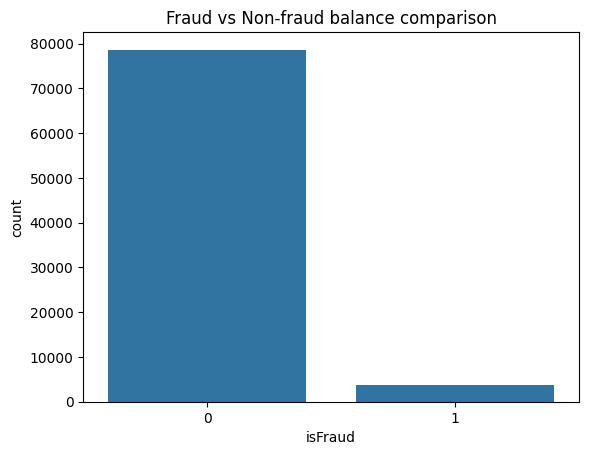

In [38]:
sns.countplot(x=df_small['isFraud'])
plt.title('Fraud vs Non-fraud balance comparison')
plt.show()

In [39]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

In [40]:
y = df_small['isFraud']
x = df_small.drop('isFraud',axis=1)

In [41]:
num_cols = x.select_dtypes(include=['float64','int64']).columns.tolist()
cat_cols = x.select_dtypes(include='object').columns.tolist()

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,shuffle=False)

In [46]:
x_test[num_cols] = num_imputed.transform(x_test[num_cols])
x_test[cat_cols] = cat_imputed.transform(x_test[cat_cols])

In [44]:
num_imputed = SimpleImputer(strategy='median')
x_train[num_cols]= num_imputed.fit_transform(x_train[num_cols])
cat_imputed = SimpleImputer(strategy='most_frequent')
x_train[cat_cols]=cat_imputed.fit_transform(x_train[cat_cols])

In [55]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

In [61]:
label_dict = {}
for col in cat_cols:
    label = LabelEncoder()
    label.fit(pd.concat([x_train[col], x_test[col]]).astype(str))
    x_train[col] = label.transform(x_train[col].astype(str))
    x_test[col] = label.transform(x_test[col].astype(str))
    label_dict[col] = label

In [71]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

In [75]:
model = LGBMClassifier(n_estimators=500,learning_rate=0.05,num_leaves=31,random_state=42,n_jobs=-1,scale_pos_weight=22 )
model.fit(x_train,y_train)
y_pred = model.predict_proba(x_test)[:, 1] 
roc_auc = roc_auc_score(y_test,y_pred)
avg_prec = average_precision_score(y_test,y_pred)
print(roc_auc)
print(avg_prec)

[LightGBM] [Info] Number of positive: 2800, number of negative: 63080
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.071249 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 20151
[LightGBM] [Info] Number of data points in the train set: 65880, number of used features: 266
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.042502 -> initscore=-3.114784
[LightGBM] [Info] Start training from score -3.114784
0.9060542166275236
0.6405129199125021


In [68]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

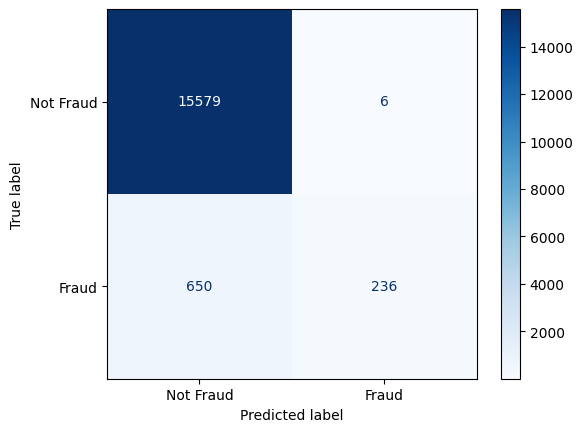

In [69]:
y_pred_labels = model.predict(x_test)
cm = confusion_matrix(y_test, y_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Fraud', 'Fraud'])
disp.plot(cmap='Blues')